<a href="https://colab.research.google.com/github/valesed/GitHub-Repository-for-CPE311/blob/main/Hands_on_Activity_9_1_Data_Visualization_using_Pandas_and_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Getting Started with Matplotlib**

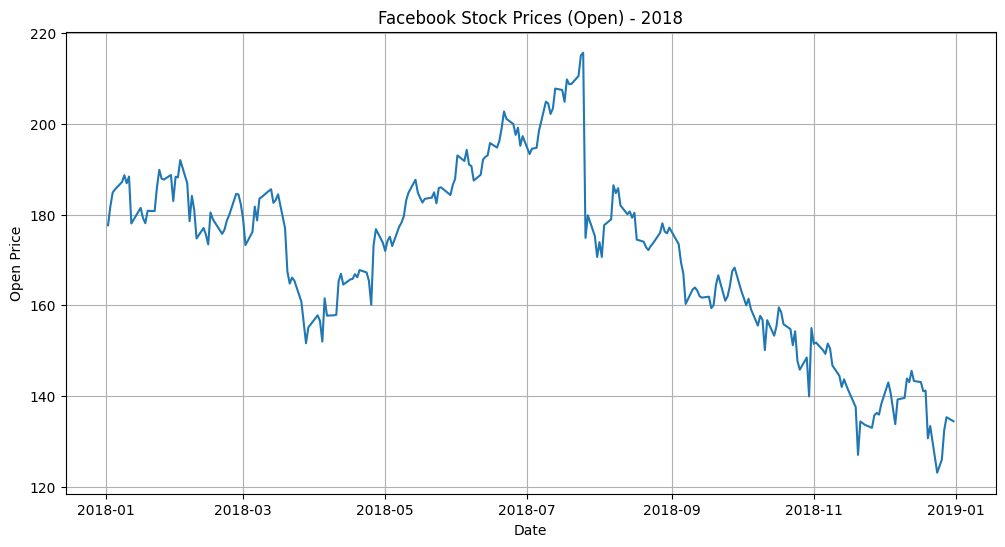

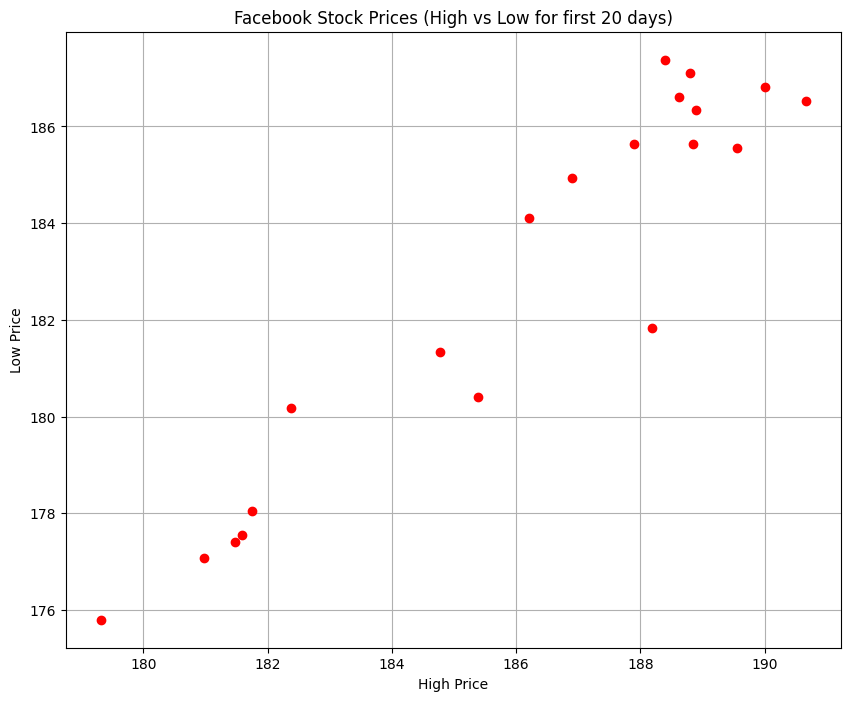

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

fb = pd.read_csv(
    '/content/fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)

plt.figure(figsize=(12, 6))
plt.plot(fb.index, fb.open)
plt.title('Facebook Stock Prices (Open) - 2018')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 8))
plt.plot('high', 'low', 'ro', data=fb.head(20))
plt.title('Facebook Stock Prices (High vs Low for first 20 days)')
plt.xlabel('High Price')
plt.ylabel('Low Price')
plt.grid(True)
plt.show()

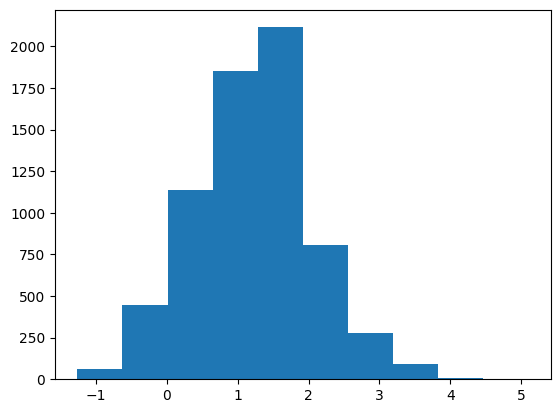

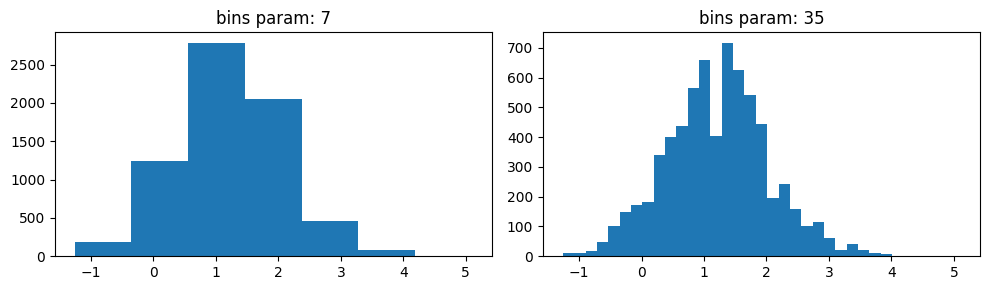

In [ ]:
quakes = pd.read_csv('/content/earthquakes-1.csv'); plt.hist(quakes.query('magType == "ml"').mag)
x = quakes.query('magType == "ml"').mag

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, bins_val in zip(axes, [7, 35]):
    ax.hist(x, bins=bins_val)
    ax.set_title(f'bins param: {bins_val}')
plt.tight_layout()
plt.show()

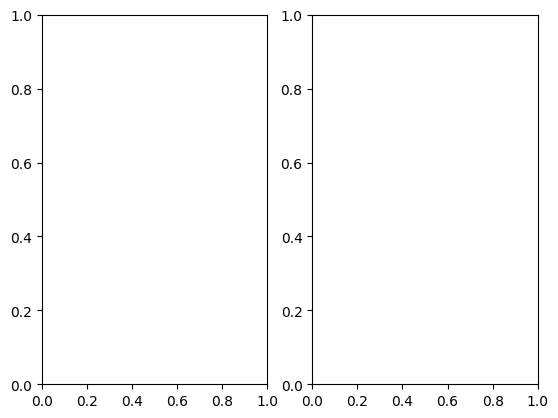

In [ ]:
fig, axes = plt.subplots(1, 2)


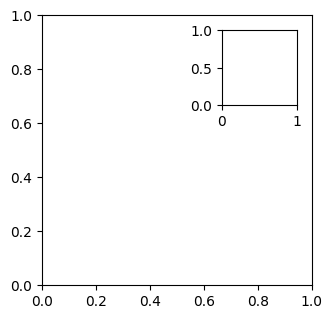

In [ ]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.9])
inside = fig.add_axes([0.7, 0.7, 0.25, 0.25])


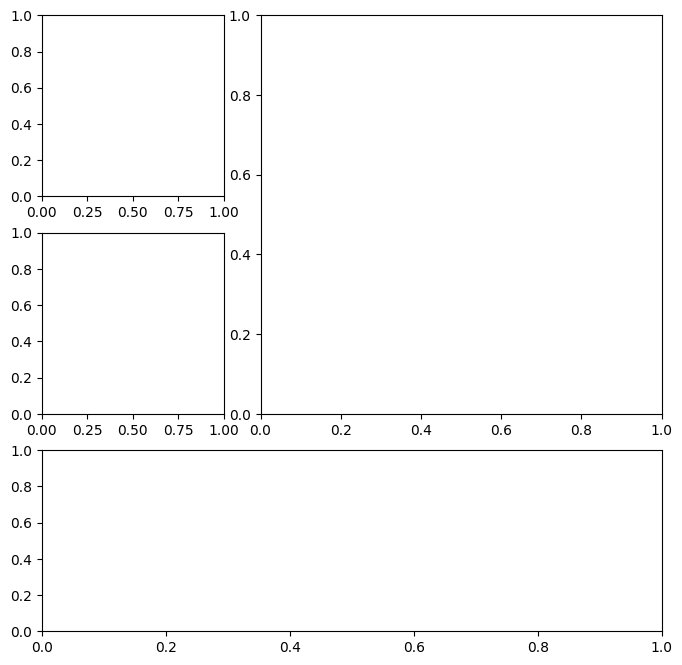

In [ ]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2,:])

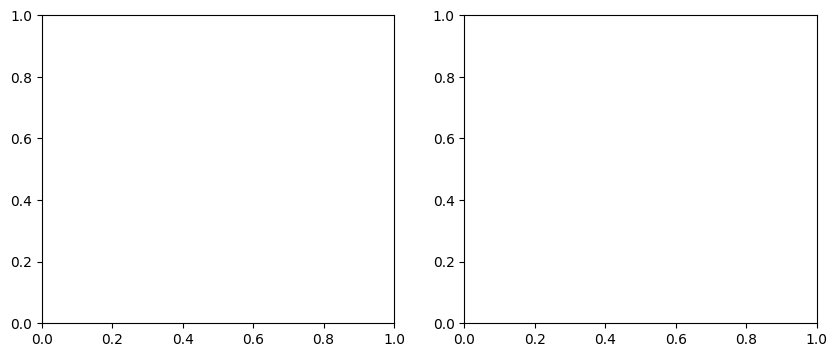

In [ ]:
fig.savefig('empty.png')
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


# **Matplotlib provides detailed control for creating and customizing visualizations.**

# **2. Plotting with Pandas**

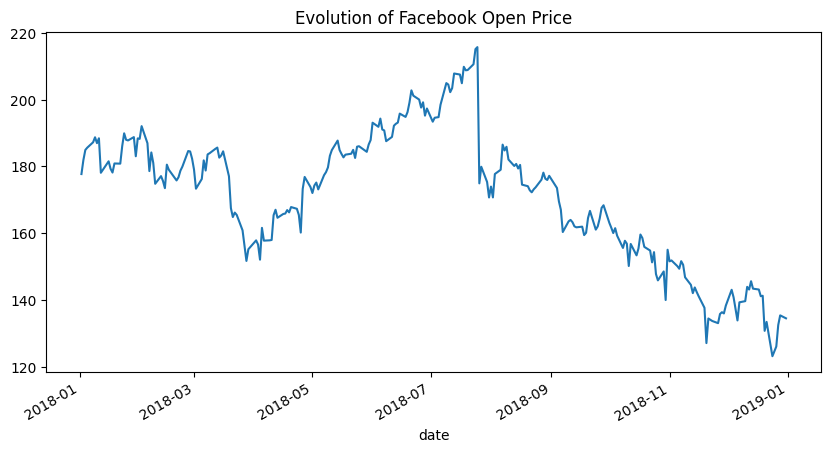

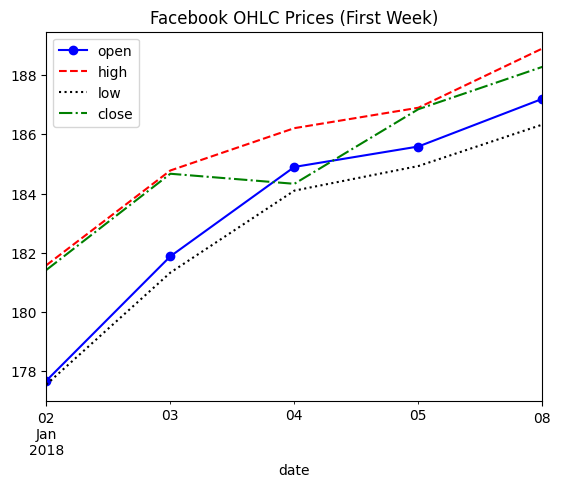

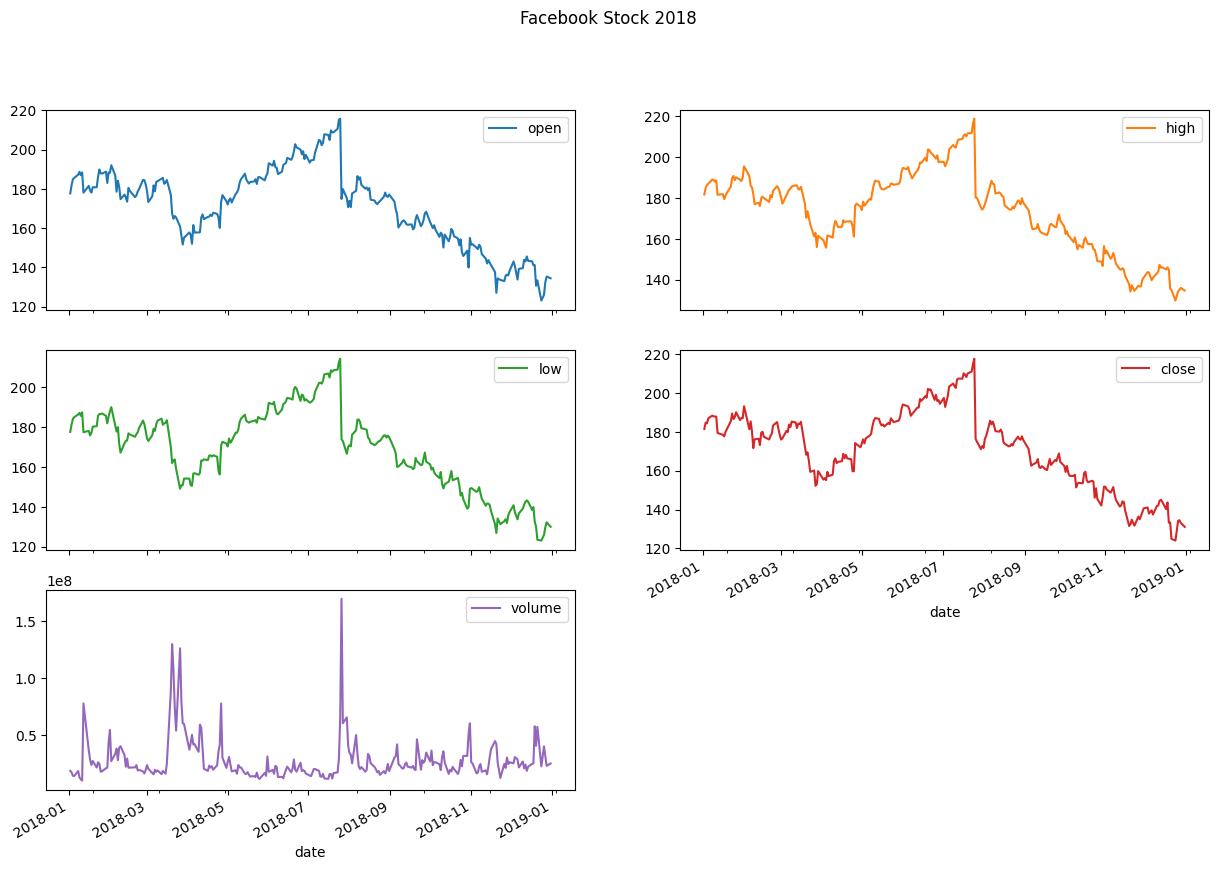

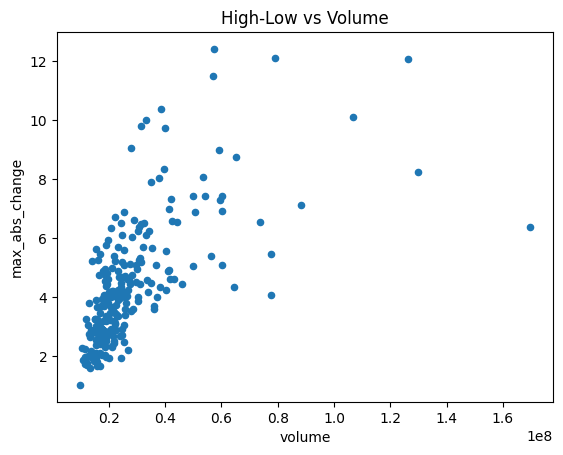

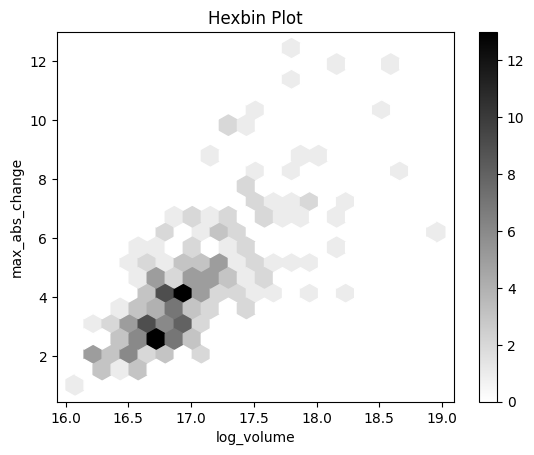

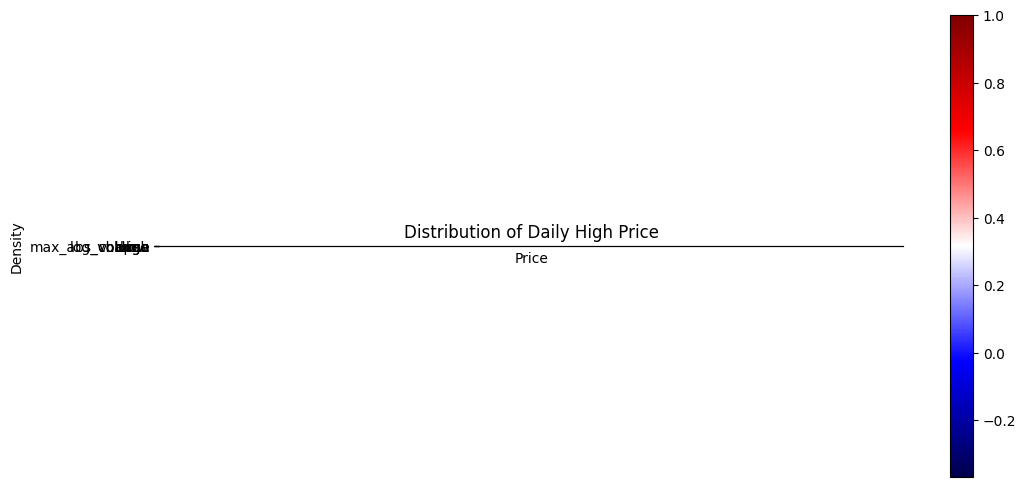

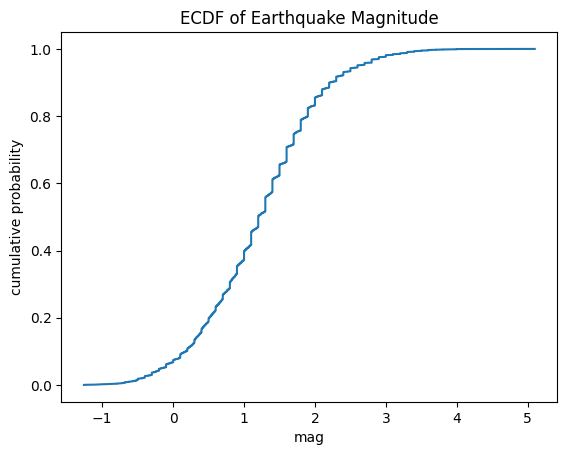

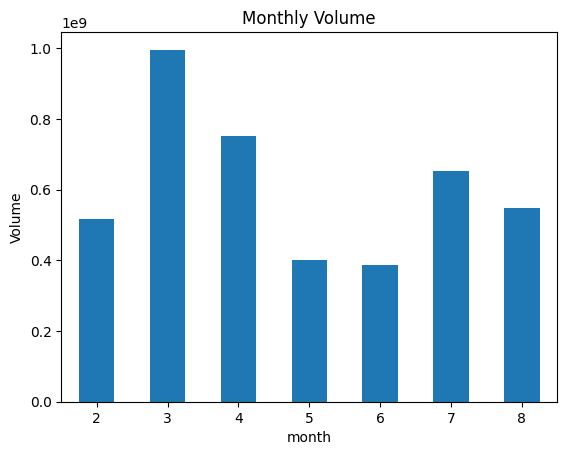

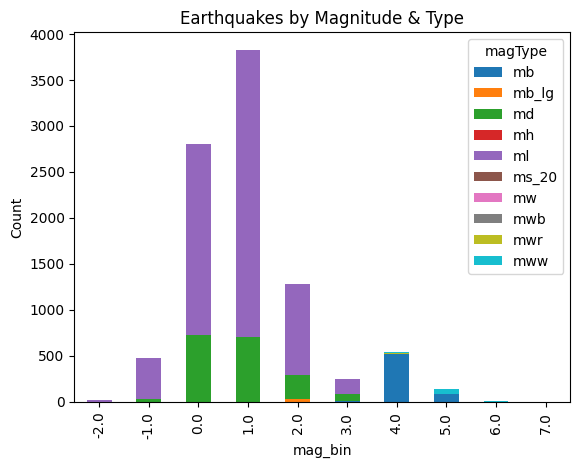

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.distributions.empirical_distribution import ECDF

fb = pd.read_csv('/content/fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
quakes = pd.read_csv('/content/earthquakes-1.csv')

fb.plot(kind='line', y='open', figsize=(10,5), legend=False,
        title='Evolution of Facebook Open Price')

fb.iloc[:5].plot(
    y=['open','high','low','close'],
    style=['b-o','r--','k:','g-.'],
    title='Facebook OHLC Prices (First Week)'
)

fb.plot(kind='line', subplots=True, layout=(3,2),
        figsize=(15,10), title='Facebook Stock 2018')

fb.assign(max_abs_change=fb.high - fb.low).plot(
    kind='scatter', x='volume', y='max_abs_change',
    title='High-Low vs Volume'
)

fb.assign(
    log_volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).plot(
    kind='hexbin',
    x='log_volume',
    y='max_abs_change',
    gridsize=20,
    colormap='gray_r',
    sharex=False,
    title='Hexbin Plot'
)

fig, ax = plt.subplots(figsize=(12,6))
fb_corr = fb.assign(
    log_volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).corr()

im = ax.matshow(fb_corr, cmap='seismic')
fig.colorbar(im)
ax.set_xticks(np.arange(len(fb_corr.columns)))
ax.set_yticks(np.arange(len(fb_corr.columns)))
ax.set_xticklabels(fb_corr.columns.tolist(), rotation=45)
ax.set_yticklabels(fb_corr.columns.tolist())

fb.volume.plot(kind='hist', title='Histogram of Volume')
plt.xlabel('Volume')

ax = fb.high.plot(kind='hist', density=True, alpha=0.5)
fb.high.plot(ax=ax, kind='kde',
             title="Distribution of Daily High Price")
plt.xlabel('Price')

ecdf = ECDF(quakes.query('magType == "ml"').mag)
plt.figure()
plt.plot(ecdf.x, ecdf.y)
plt.xlabel('mag')
plt.ylabel('cumulative probability')
plt.title('ECDF of Earthquake Magnitude')

fb.iloc[:,:4].plot(kind='box', title='Facebook OHLC Boxplot')
plt.ylabel('Price')

fb['2018-02':'2018-08'].assign(
    month=lambda x: x.index.month
).groupby('month').sum().volume.plot.bar(
    rot=0, title='Monthly Volume'
)
plt.ylabel('Volume')

pivot = quakes.assign(
    mag_bin=lambda x: np.floor(x.mag)
).pivot_table(
    index='mag_bin',
    columns='magType',
    values='mag',
    aggfunc='count'
)

pivot.fillna(0).plot.bar(stacked=True,
                         title='Earthquakes by Magnitude & Type')
plt.ylabel('Count')

plt.show()

# **Pandas makes exploratory data analysis faster and more efficient while still producing informative visualizations.**

# **3. Pandas Plotting Subpackage**

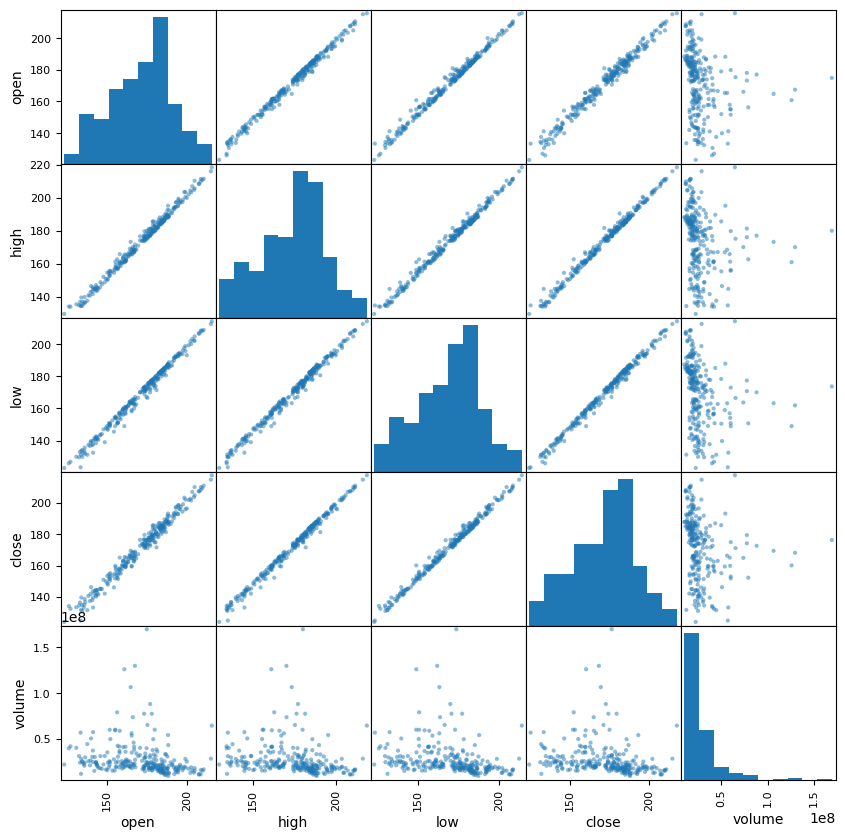

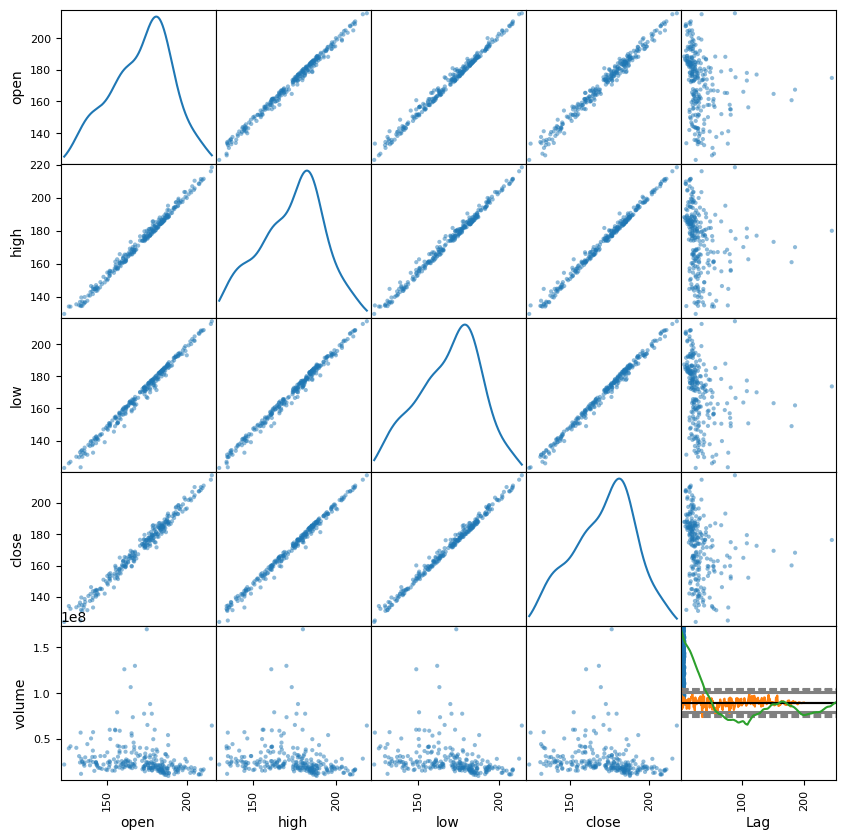

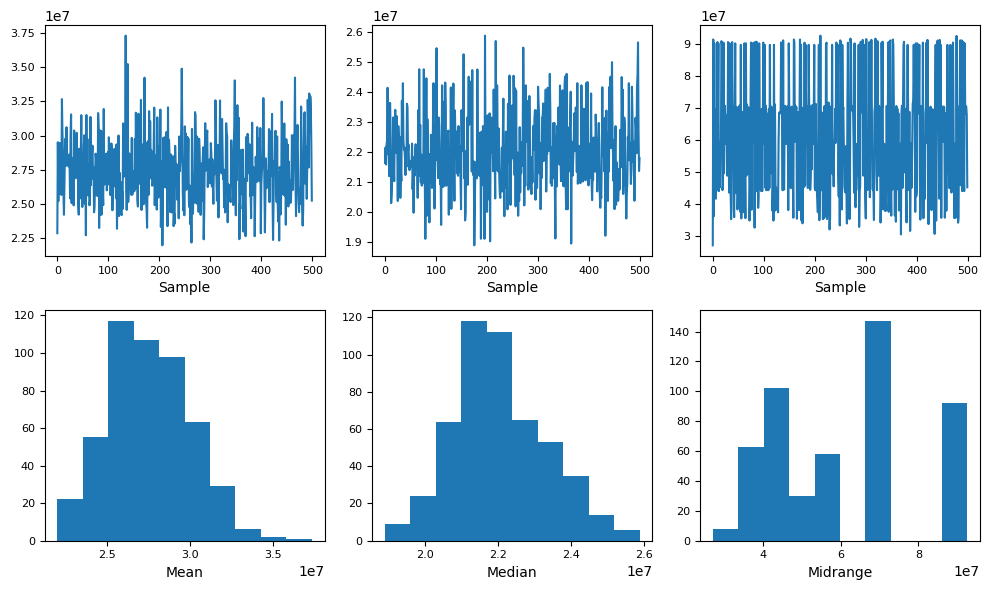

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.plotting import (
    scatter_matrix,
    lag_plot,
    autocorrelation_plot,
    bootstrap_plot
)

fb = pd.read_csv('/content/fb_stock_prices_2018.csv',
                 index_col='date',
                 parse_dates=True)

scatter_matrix(fb, figsize=(10,10))
scatter_matrix(fb, figsize=(10,10), diagonal='kde')

np.random.seed(0)
lag_plot(pd.Series(np.random.random(size=200)))

lag_plot(fb.close)
lag_plot(fb.close, lag=5)

np.random.seed(0)
autocorrelation_plot(pd.Series(np.random.random(size=200)))

autocorrelation_plot(fb.close)

bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10,6)))

plt.show()

# **The plotting subpackage is useful for statistical analysis and identifying time-series behavior.**

# **Supplementary Activity:**

 **Using the CSV files provided and what we have learned so far in this module complete the following exercises:**


1.  Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method.

2.  Create a histogram and KDE of the change from open to close in the price of Facebook stock.

3.   Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

4.   Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.

5.   Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:




   *   The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review the Time series section of Aggregating Pandas DataFrames for an easy way to do this).

  *   The second subplot will be a bar plot showing the net effect this had monthly, using resample().

  *   Bonus #1: Color the bars according to whether they are gains in the stock price (green) or drops in the stock price (red).

  *   Bonus #2: Modify the x-axis of the bar plot to show the threeletter abbreviation for the month.











    

    

    

    


        

        

        

        


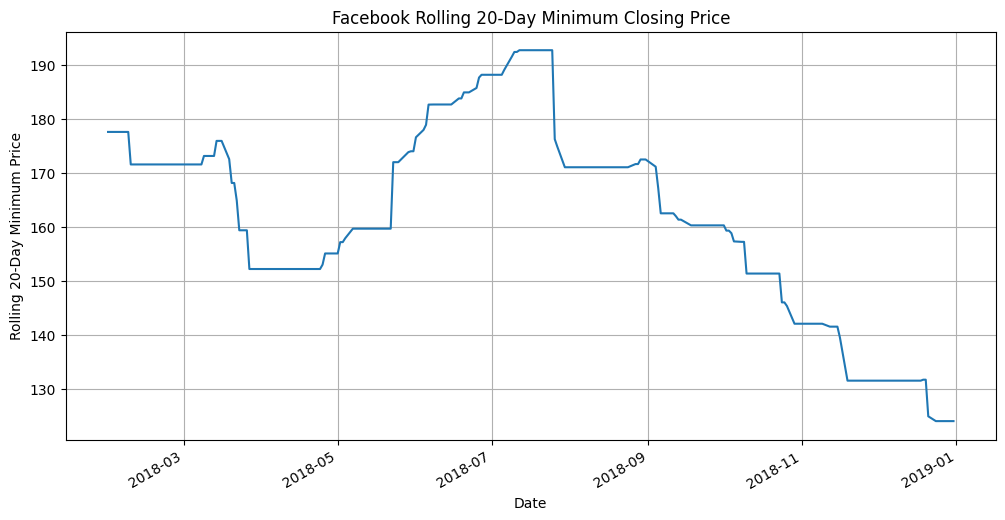

In [ ]:
fb_min_20d = fb['close'].rolling(window=20).min()

fig, ax = plt.subplots(figsize=(12, 6))
fb_min_20d.plot(ax=ax)
ax.set_title('Facebook Rolling 20-Day Minimum Closing Price')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling 20-Day Minimum Price')
plt.grid(True)
plt.show()

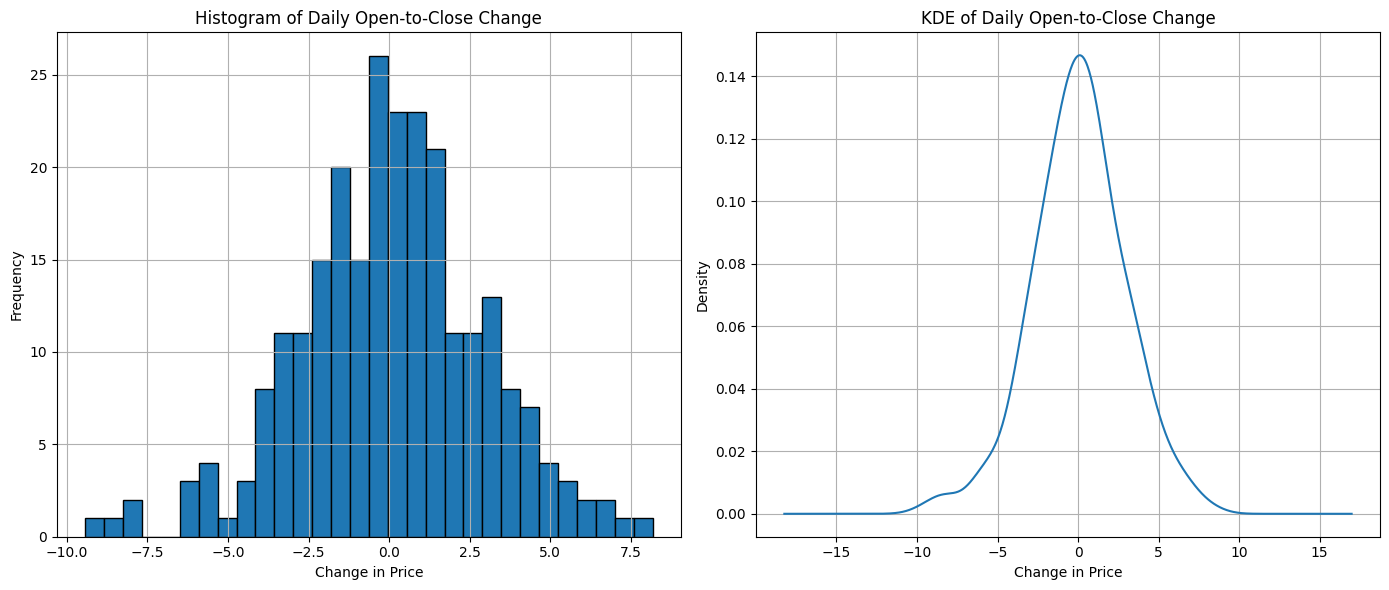

In [ ]:
fb_daily_change = fb['close'] - fb['open']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(fb_daily_change, bins=30, edgecolor='black')
axes[0].set_title('Histogram of Daily Open-to-Close Change')
axes[0].set_xlabel('Change in Price')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

fb_daily_change.plot(kind='kde', ax=axes[1])
axes[1].set_title('KDE of Daily Open-to-Close Change')
axes[1].set_xlabel('Change in Price')
axes[1].set_ylabel('Density')
axes[1].grid(True)

plt.tight_layout()
plt.show()

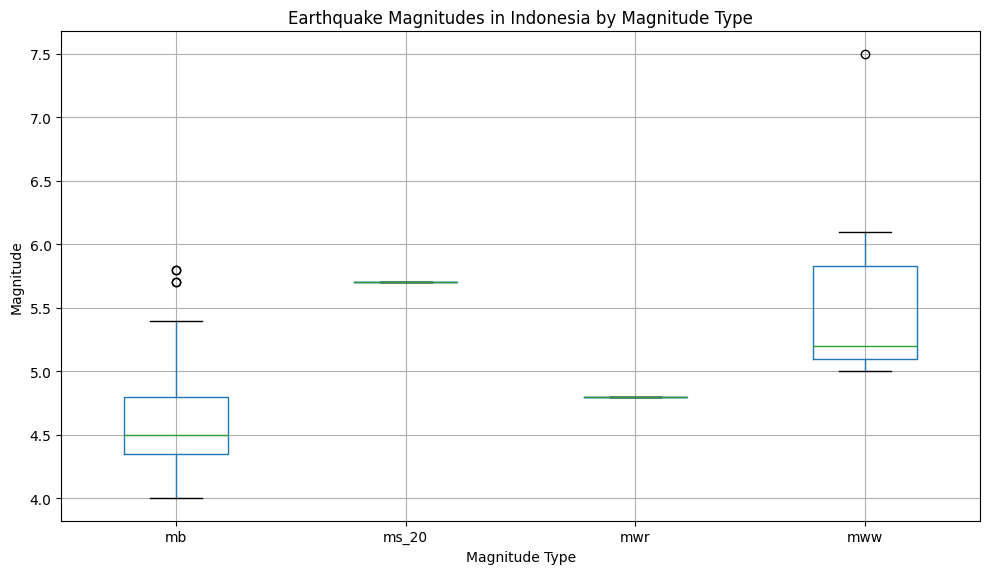

In [ ]:
indonesia_quakes = quakes[quakes['place'].str.contains('Indonesia', na=False)]

fig, ax = plt.subplots(figsize=(10, 6))
indonesia_quakes.boxplot(column='mag', by='magType', ax=ax)

ax.set_title('Earthquake Magnitudes in Indonesia by Magnitude Type')
ax.set_xlabel('Magnitude Type')
ax.set_ylabel('Magnitude')

plt.suptitle('')
plt.tight_layout()
plt.show()

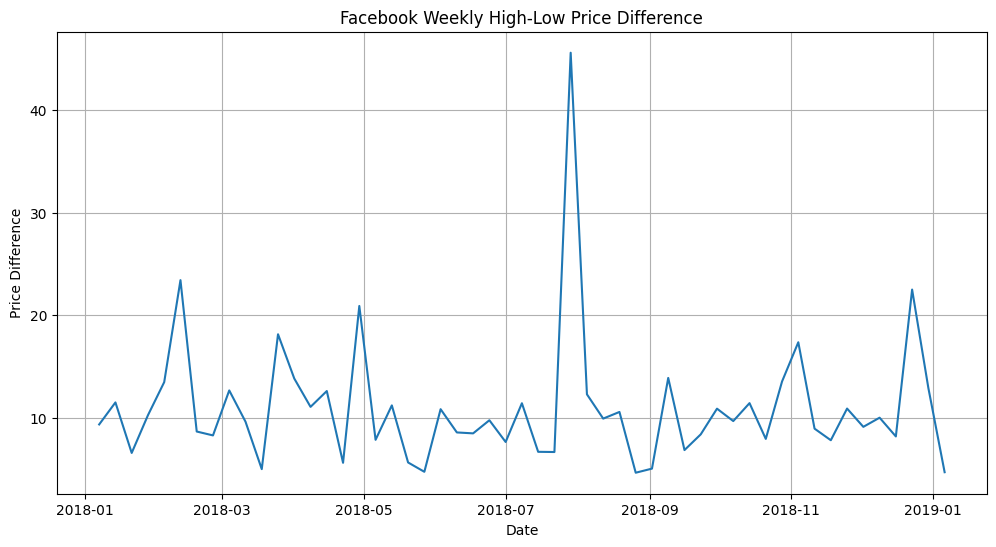

In [ ]:
weekly_data = fb.resample('W').agg({
    'high': 'max',
    'low': 'min'
})

weekly_data['high_low_diff'] = weekly_data['high'] - weekly_data['low']
plt.figure(figsize=(12, 6))
plt.plot(weekly_data.index, weekly_data['high_low_diff'])
plt.title('Facebook Weekly High-Low Price Difference')
plt.xlabel('Date')
plt.ylabel('Price Difference')
plt.grid(True)
plt.show()

/tmp/ipykernel_639/2282333564.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_net_change = after_hours_change.resample('M').sum()


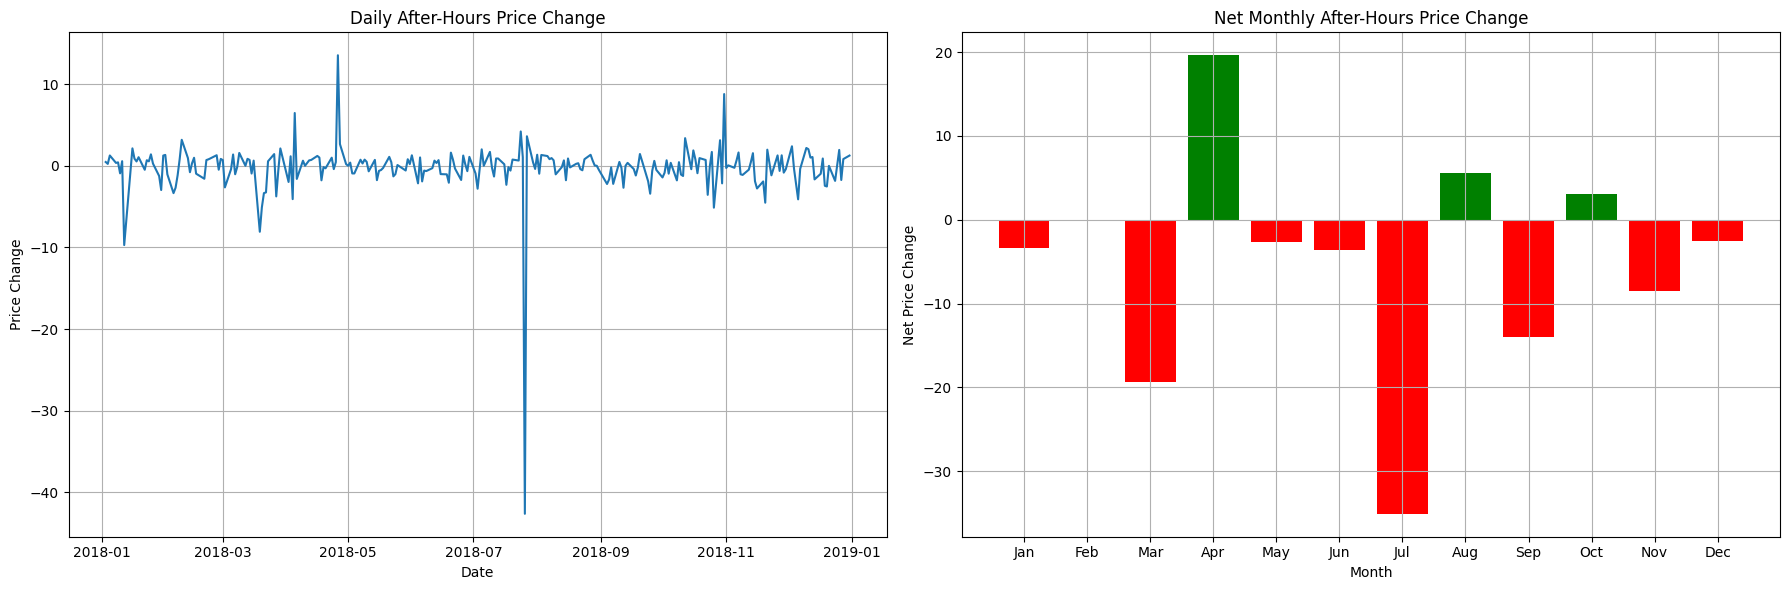

In [ ]:
after_hours_change = fb['open'] - fb['close'].shift(1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.plot(after_hours_change.index, after_hours_change)
ax1.set_title('Daily After-Hours Price Change')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price Change')
ax1.grid(True)

monthly_net_change = after_hours_change.resample('M').sum()
colors = ['green' if x > 0 else 'red' for x in monthly_net_change]
ax2.bar(monthly_net_change.index.strftime('%b'), monthly_net_change, color=colors)
ax2.set_title('Net Monthly After-Hours Price Change')
ax2.set_xlabel('Month')
ax2.set_ylabel('Net Price Change')
ax2.grid(True)

plt.tight_layout()
plt.show()

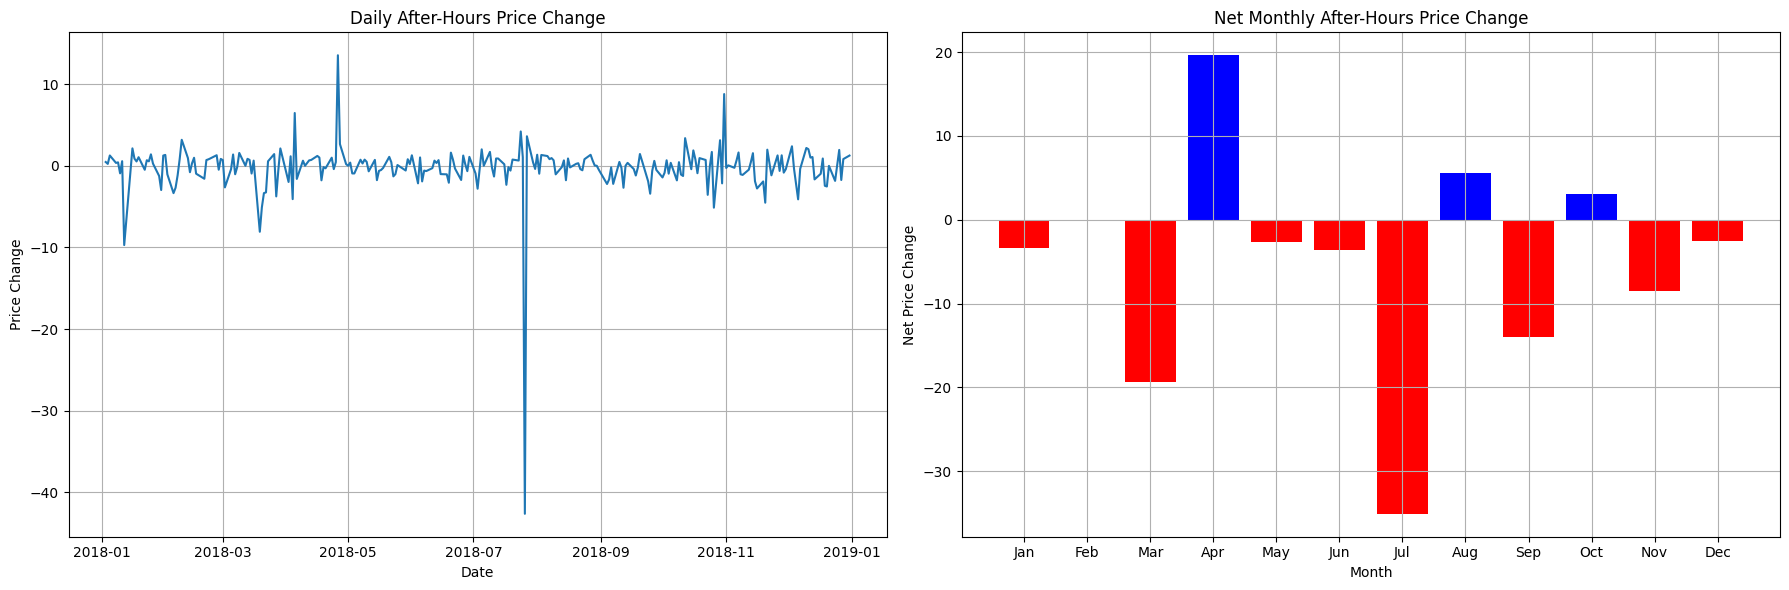

In [ ]:
after_hours_change = fb['open'] - fb['close'].shift(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(after_hours_change.index, after_hours_change)
ax1.set_title('Daily After-Hours Price Change')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price Change')
ax1.grid(True)

monthly_net_change = after_hours_change.resample('ME').sum()
colors = ['blue' if x > 0 else 'red' for x in monthly_net_change]
ax2.bar(monthly_net_change.index.strftime('%b'), monthly_net_change, color=colors)
ax2.set_title('Net Monthly After-Hours Price Change')
ax2.set_xlabel('Month')
ax2.set_ylabel('Net Price Change')
ax2.grid(True)

plt.tight_layout()
plt.show()

# **The visualizations demonstrate Data visualization helps make patterns, trends, and relationships easier to understand compared to just looking at raw numbers.**

#**Matplotlib offers full customization, while Pandas provides faster and more efficient plotting for data analysis.**